In [7]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon,kstest
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 2.7
control_thresh = 2.9

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [8]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control =  ['BS_42','BS_108','BS_56','BS_72','BS_70','BS_87','AE_312']

all_animals = np.concatenate([post_opto, post_control])

In [9]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3f.csv'))

In [10]:
df

,Unnamed: 0,animal,session,phase,condition,FR modulation
0,0,BS_119,BS_119_4_opto_AC.pickle,2,opto,1.426282
1,1,BS_119,BS_119_5_opto_AC.pickle,2,opto,6.858586
2,2,BS_119,BS_119_5_opto_AC.pickle,2,opto,5.067568
3,3,BS_119,BS_119_5_opto_AC.pickle,2,opto,4.449495
4,4,BS_119,BS_119_5_opto_AC.pickle,2,opto,2.156566
...,...,...,...,...,...,...
389,389,AE_312,AE_312_5_opto_control_AC.pickle,post late,control,2.485549
390,390,AE_312,AE_312_5_opto_control_AC.pickle,post late,control,22.208589
391,391,AE_312,AE_312_5_opto_control_AC.pickle,post late,control,1.013460
392,392,AE_312,AE_312_5_opto_control_AC.pickle,post late,control,5.359712


In [11]:
FRmod_control = []
FRmod_opto = []

for row in df.iloc():
    
    if row['condition'] == 'control':
        if row['phase'] == 'post late':
            FRmod_control.append(row['FR modulation'])

        
    if row['condition'] == 'opto':
        if row['phase'] == '2':
            FRmod_opto.append(row['FR modulation'])
        
FRmod_control = np.array(FRmod_control)
FRmod_opto = np.array(FRmod_opto)

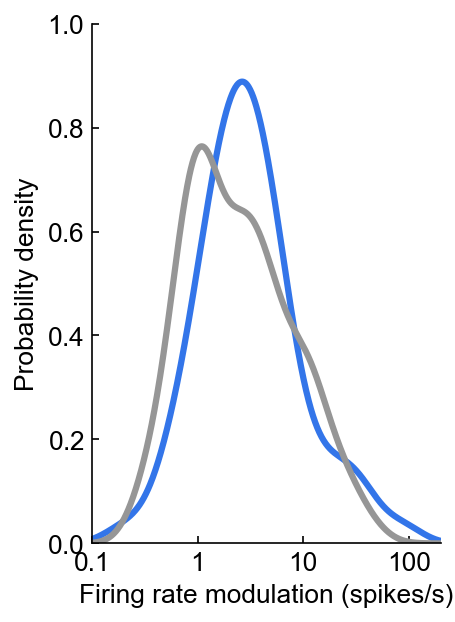

In [12]:
fig, ax = plt.subplots(figsize=(3,4.5))

x = np.logspace(-2, 3, 1000) 
z = np.log10(x)

KDE = gaussian_kde(np.log10(FRmod_opto), bw_method='scott')
KDE_eval = KDE.evaluate(z)
ymax_CR = np.max(KDE_eval)
ax.plot(x,KDE_eval,color=LASER_COLOR,label='opto',lw=3)

KDE = gaussian_kde(np.log10(FRmod_control), bw_method='scott')
KDE_eval = KDE.evaluate(z)
ymax_NCR = np.max(KDE_eval)
ax.plot(x,KDE_eval,color=GOOD_GREY,label='control',lw=3)


ax.set_xlabel('Firing rate modulation (spikes/s)')
ax.set_xscale('log',subs=[])
ax.set_xlim([0.1,200])
ax.set_xticks([0.1,1,10,100])
ax.set_xticklabels(['0.1','1','10','100'])


ax.set_ylim([0,1])
ax.set_ylabel('Probability density')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont*0.9)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass


# fig.savefig(os.path.join('..','..','Figures','Figure 3f.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [13]:
test = kstest(FRmod_opto,FRmod_control)
print('Opto vs control')
print(f'p = {test.pvalue}')

Opto vs control
p = 0.002991041582592507
